## Class 6 - Case Study 1

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
movies = pd.read_csv("DataSets/HollywoodMovies.csv")
movies.head()

,Movie,LeadStudio,RottenTomatoes,AudienceScore,Story,Genre,TheatersOpenWeek,OpeningWeekend,BOAvgOpenWeekend,DomesticGross,ForeignGross,WorldGross,Budget,Profitability,OpenProfit,Year
0,Spider-Man 3,Sony,61.0,54.0,Metamorphosis,Action,4252.0,151.1,35540.0,336.53,554.34,890.87,258.0,345.30,58.57,2007
1,Shrek the Third,Paramount,42.0,57.0,Quest,Animation,4122.0,121.6,29507.0,322.72,476.24,798.96,160.0,499.35,76.00,2007
2,Transformers,Paramount,57.0,89.0,Monster Force,Action,4011.0,70.5,17577.0,319.25,390.46,709.71,150.0,473.14,47.00,2007
3,Pirates of the Caribbean: At World's End,Disney,45.0,74.0,Rescue,Action,4362.0,114.7,26302.0,309.42,654.00,963.42,300.0,321.14,38.23,2007
4,Harry Potter and the Order of the Phoenix,Warner Bros,78.0,82.0,Quest,Adventure,4285.0,77.1,17998.0,292.00,647.88,939.89,150.0,626.59,51.40,2007


In [5]:
# 1. Highest-rated movie in "Quest" story type
quest_movies = movies[movies['Story'].str.lower() == 'quest']
highest_rated_quest = quest_movies.loc[quest_movies['AudienceScore'].idxmax()]
print("Highest-rated 'Quest' movie:")
print(f"Movie: {highest_rated_quest['Movie']}, Rating: {highest_rated_quest['AudienceScore']}")


Highest-rated 'Quest' movie:
Movie: Into the Wild, Rating: 90.0


In [6]:
movies.columns

Index(['Movie', 'LeadStudio', 'RottenTomatoes', 'AudienceScore', 'Story',
       'Genre', 'TheatersOpenWeek', 'OpeningWeekend', 'BOAvgOpenWeekend',
       'DomesticGross', 'ForeignGross', 'WorldGross', 'Budget',
       'Profitability', 'OpenProfit', 'Year'],
      dtype='object')

In [7]:
# 2. Genre with greatest number of releases
genre_counts = movies['Genre'].value_counts()
print("\nGenre with greatest number of releases:")
print(f"Genre: {genre_counts.idxmax()}, Number of releases: {genre_counts.max()}")



Genre with greatest number of releases:
Genre: Comedy, Number of releases: 177


In [8]:
# 3. Top five movies with the costliest budgets
top_5_budget_movies = movies.sort_values(by='Budget', ascending=False).head(5)['Movie'].tolist()
print("\nTop five movies with the costliest budgets:")
for i, movie in enumerate(top_5_budget_movies, start=1):
    print(f"{i}. {movie}")



Top five movies with the costliest budgets:
1. Pirates of the Caribbean: At World's End
2. Tangled
3. Spider-Man 3
4. The Dark Knight Rises
5. Harry Potter and the Half-Blood Prince


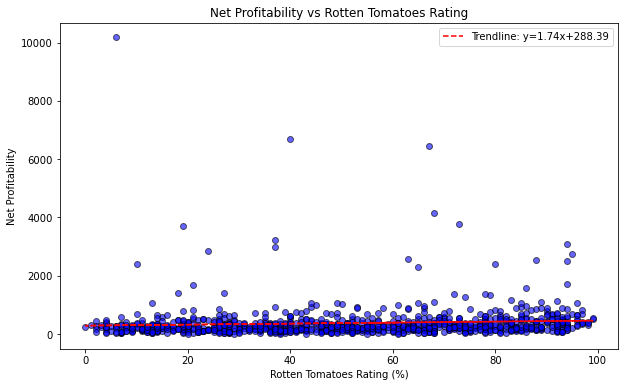

In [12]:
#Is there any correspondence between the critics’ evaluation of a movie and itsacceptance by the public? Find out, by plotting the net profitability of a movie against the ratings it receives on Rotten Tomatoes.
# Select relevant columns and drop missing values
plot_data = movies[['RottenTomatoes', 'Profitability']].dropna()

# Extract x and y values
x = plot_data['RottenTomatoes']
y = plot_data['Profitability']

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, color='blue', edgecolors='k')
plt.title('Net Profitability vs Rotten Tomatoes Rating')
plt.xlabel('Rotten Tomatoes Rating (%)')
plt.ylabel('Net Profitability')

# Add trendline
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), "r--", label=f'Trendline: y={z[0]:.2f}x+{z[1]:.2f}')
plt.legend()

# Show plot
plt.show()


## Perform Operations on Files

5.1: From the raw data below create a data frame
'first_name': ['Jason', 'Molly', 'Tina', 'Jake', 'Amy'],
'last_name': ['Miller', 'Jacobson', ".", 'Milner', 'Cooze'], 
'age': [42, 52, 36, 24, 73], 'preTestScore': [4, 24, 31, ".", "."],'postTestScore': ["25,000", "94,000", 57, 62, 70]

In [3]:
import pandas as pd
import numpy as np

# Raw data
raw = {
    'first_name': ['Jason', 'Molly', 'Tina', 'Jake', 'Amy'],
    'last_name': ['Miller', 'Jacobson', '.', 'Milner', 'Cooze'],
    'age': [42, 52, 36, 24, 73],
    'preTestScore': [4, 24, 31, '.', '.'],
    'postTestScore': ['25,000', '94,000', 57, 62, 70]
}

# Create DataFrame
df = pd.DataFrame(raw)
df


,first_name,last_name,age,preTestScore,postTestScore
0,Jason,Miller,42,4,"25,000"
1,Molly,Jacobson,52,24,"94,000"
2,Tina,.,36,31,57
3,Jake,Milner,24,.,62
4,Amy,Cooze,73,.,70


In [6]:
# Step 5.2: Save the DataFrame into a CSV file
df.to_csv('DataSets/example.csv', index=False)


In [7]:

# Step 5.3: Read the example.csv and print the DataFrame
df_with_header = pd.read_csv('DataSets/example.csv')
print("DataFrame with headers:\n", df_with_header)


DataFrame with headers:
   first_name last_name  age preTestScore postTestScore
0      Jason    Miller   42            4        25,000
1      Molly  Jacobson   52           24        94,000
2       Tina         .   36           31            57
3       Jake    Milner   24            .            62
4        Amy     Cooze   73            .            70


In [12]:
#5.5 Read the CSV file
df = pd.read_csv('DataSets/example.csv')

# Clean up: replace '.' with NaN
df = df.replace('.', np.nan)

# Set 'first_name' and 'last_name' as index columns
df.set_index(['first_name', 'last_name'], inplace=True)

# Print the DataFrame
print(df)



                      age preTestScore postTestScore
first_name last_name                                
Jason      Miller      42            4        25,000
Molly      Jacobson    52           24        94,000
Tina       NaN         36           31            57
Jake       Milner      24          NaN            62
Amy        Cooze       73          NaN            70


In [13]:
df.isnull()

,,age,preTestScore,postTestScore
first_name,last_name,,,
Jason,Miller,False,False,False
Molly,Jacobson,False,False,False
Tina,NaN,False,False,False
Jake,Milner,False,True,False
Amy,Cooze,False,True,False


In [16]:
# Read the CSV file, skipping the first 3 rows
df_skipped = pd.read_csv('DataSets/example.csv', skiprows=3)

# Print the DataFrame
print(df_skipped)


   Tina       .  36 31  57
0  Jake  Milner  24  .  62
1   Amy   Cooze  73  .  70


In [17]:
import pandas as pd

# Load the CSV file and interpret commas as thousands separators
df = pd.read_csv('DataSets/example.csv', thousands=',')

# Print the DataFrame
print(df)


  first_name last_name  age preTestScore  postTestScore
0      Jason    Miller   42            4          25000
1      Molly  Jacobson   52           24          94000
2       Tina         .   36           31             57
3       Jake    Milner   24            .             62
4        Amy     Cooze   73            .             70


## 6.Perform Operations on Files

6.1: From the raw data below create a Pandas Series'Amit', 'Bob', 'Kate', 'A', 'b', np.nan, 'Car', 'dog', 'cat'a) Print all elements in lower caseb) Print all the elements in upper casec) Print the length of all the elements

In [19]:
import pandas as pd
import numpy as np

# Raw data
data = ['Amit', 'Bob', 'Kate', 'A', 'b', np.nan, 'Car', 'dog', 'cat']

# Create Pandas Series
s = pd.Series(data)

# a) Print all elements in lower case
print("Lower case:\n", s.str.lower())

# b) Print all elements in upper case
print("\nUpper case:\n", s.str.upper())

# c) Print the length of all elements
print("\nLength of elements:\n", s.str.len())


Lower case:
 0    amit
1     bob
2    kate
3       a
4       b
5     NaN
6     car
7     dog
8     cat
dtype: object

Upper case:
 0    AMIT
1     BOB
2    KATE
3       A
4       B
5     NaN
6     CAR
7     DOG
8     CAT
dtype: object

Length of elements:
 0    4.0
1    3.0
2    4.0
3    1.0
4    1.0
5    NaN
6    3.0
7    3.0
8    3.0
dtype: float64


6.2: From the raw data below create a Pandas Series' Atul', 'John ', ' jack ', 'Sam'a) Print all elements after stripping spaces from the left and rightb) Print all the elements after removing spaces from the left onlyc) Print all the elements after removing spaces from the right only

In [20]:
import pandas as pd

# Raw data
data = [' Atul', 'John ', ' jack ', 'Sam']

# Create Pandas Series
s = pd.Series(data)

# a) Strip spaces from both left and right
print("Strip spaces from both sides:\n", s.str.strip())

# b) Remove spaces from the left only
print("\nStrip spaces from left:\n", s.str.lstrip())

# c) Remove spaces from the right only
print("\nStrip spaces from right:\n", s.str.rstrip())


Strip spaces from both sides:
 0    Atul
1    John
2    jack
3     Sam
dtype: object

Strip spaces from left:
 0     Atul
1    John 
2    jack 
3      Sam
dtype: object

Strip spaces from right:
 0     Atul
1     John
2     jack
3      Sam
dtype: object


6.3: -Create a series from the raw data below'India_is_big', 'Population_is_huge', np.nan, 'Has_diverse_culture'a)split the individual strings wherever ‘_’ comes and create a list out of it.b)Access the individual elementsof a listc)Expand the elements so that all individual elements get splitby ‘_’ and insteadof list returns individual elements

In [21]:
import pandas as pd
import numpy as np

# Raw data
data = ['India_is_big', 'Population_is_huge', np.nan, 'Has_diverse_culture']

# Create Pandas Series
s = pd.Series(data)

# a) Split the individual strings wherever '_' comes and create a list out of it
print("Split into lists:\n", s.str.split('_'))

# b) Access the individual elements of a list (example: first element of each list)
print("\nFirst element of each list:\n", s.str.split('_').str[0])

# c) Expand the elements so that all individual elements get split by '_' and return as separate columns
print("\nExpanded split elements:\n", s.str.split('_', expand=True))


Split into lists:
 0           [India, is, big]
1     [Population, is, huge]
2                        NaN
3    [Has, diverse, culture]
dtype: object

First element of each list:
 0         India
1    Population
2           NaN
3           Has
dtype: object

Expanded split elements:
             0        1        2
0       India       is      big
1  Population       is     huge
2         NaN      NaN      NaN
3         Has  diverse  culture


6.4: Create a series and replace either X or dog with XX-XX'A', 'B', 'C', 'AabX', 'BacX','', np.nan, 'CABA', 'dog', 'cat

In [22]:

import pandas as pd
import numpy as np

# Raw data
data = ['A', 'B', 'C', 'AabX', 'BacX', '', np.nan, 'CABA', 'dog', 'cat']

# Create Pandas Series
s = pd.Series(data)

# Replace either 'X' or 'dog' with 'XX-XX'
print("After replacement:\n", s.replace(['X', 'dog'], 'XX-XX', regex=True))


After replacement:
 0           A
1           B
2           C
3    AabXX-XX
4    BacXX-XX
5            
6         NaN
7        CABA
8       XX-XX
9         cat
dtype: object


# 6.5: Create a series and remove the dollarsfrom the numeric values'12', '-$10', '$10,000

In [23]:

import pandas as pd
import numpy as np

# Raw data
data = ['12', '-$10', '$10,000']

# Create Pandas Series
s = pd.Series(data)

# Remove the dollar sign and commas, then convert to numeric
cleaned = s.str.replace('$', '', regex=False).str.replace(',', '', regex=False)
cleaned = pd.to_numeric(cleaned, errors='coerce')

print("Original Series:\n", s)
print("\nCleaned numeric Series:\n", cleaned)


Original Series:
 0         12
1       -$10
2    $10,000
dtype: object

Cleaned numeric Series:
 0       12
1      -10
2    10000
dtype: int64


# 6.6:-Create a series and reverse all lower case words'India1998', 'big country', np.nan

In [24]:

import pandas as pd
import numpy as np

# Raw data
data = ['India1998', 'big country', np.nan]

# Create Pandas Series
s = pd.Series(data)

# Reverse all lowercase words
# Steps:
# 1. Split each string into words
# 2. Reverse words that are fully lowercase
def reverse_lowercase_words(text):
    if pd.isna(text):
        return text
    words = text.split()
    reversed_words = [w[::-1] if w.islower() else w for w in words]
    return ' '.join(reversed_words)

# Apply the function
result = s.apply(reverse_lowercase_words)

print("Original Series:\n", s)
print("\nSeries after reversing lowercase words:\n", result)


Original Series:
 0      India1998
1    big country
2            NaN
dtype: object

Series after reversing lowercase words:
 0      India1998
1    gib yrtnuoc
2            NaN
dtype: object


# 6.7: Create pandas series and print true if the value is alphanumeric in series or false if the value is not alphanumericin series.'1', '2', '1a', '2b', '2003c

In [25]:

import pandas as pd

# Raw data
data = ['1', '2', '1a', '2b', '2003c']

# Create Pandas Series
s = pd.Series(data)

# Check if each value is alphanumeric (True if alphanumeric, False otherwise)
print("Alphanumeric check:\n", s.str.isalnum())


Alphanumeric check:
 0    True
1    True
2    True
3    True
4    True
dtype: bool


# 6.8: Create pandas series and print true if the value is containing ‘A’'1', '2', '1a', '2b', 'America', 'VietnAm','vietnam', '2003c

In [26]:

import pandas as pd

# Raw data
data = ['1', '2', '1a', '2b', 'America', 'VietnAm', 'vietnam', '2003c']

# Create Pandas Series
s = pd.Series(data)

# Check if each value contains 'A' (case-sensitive)
print("Contains 'A':\n", s.str.contains('A', na=False))


Contains 'A':
 0    False
1    False
2    False
3    False
4     True
5     True
6    False
7    False
dtype: bool


# 6.9: Create pandas series and print in three columns value 0 or 1 is a or b or c exists in values'a', 'a|b', np.nan, 'a|c'

In [27]:

import pandas as pd
import numpy as np

# Raw data
data = ['a', 'a|b', np.nan, 'a|c']

# Create Pandas Series
s = pd.Series(data)

# Check if 'a', 'b', or 'c' exists in each value and return 0/1 in three columns
result = pd.DataFrame({
    'a_exists': s.str.contains('a', na=False).astype(int),
    'b_exists': s.str.contains('b', na=False).astype(int),
    'c_exists': s.str.contains('c', na=False).astype(int)
})

print("Original Series:\n", s)
print("\nResult (0 or 1 for a, b, c):\n", result)


Original Series:
 0      a
1    a|b
2    NaN
3    a|c
dtype: object

Result (0 or 1 for a, b, c):
    a_exists  b_exists  c_exists
0         1         0         0
1         1         1         0
2         0         0         0
3         1         0         1


# 6.10: Create pandas dataframe having keys and ltable and rtable as below -'key': ['One', 'Two'], 'ltable': [1, 2]'key': ['One', 'Two'], 'rtable': [4, 5]Merge both the tables based onkey

In [28]:

import pandas as pd

# Left table
left = pd.DataFrame({
    'key': ['One', 'Two'],
    'ltable': [1, 2]
})

# Right table
right = pd.DataFrame({
    'key': ['One', 'Two'],
    'rtable': [4, 5]
})

# Merge both tables based on 'key'
merged = pd.merge(left, right, on='key')

print("Merged DataFrame:\n", merged)


Merged DataFrame:
    key  ltable  rtable
0  One       1       4
1  Two       2       5
